In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip chest_xray.zip

Archive:  chest_xray.zip
   creating: chest_xray/
   creating: chest_xray/test/
   creating: chest_xray/test/NORMAL/
  inflating: chest_xray/test/NORMAL/NORMAL2-IM-0988-0001.jpeg  
  inflating: chest_xray/test/NORMAL/NORMAL2-IM-0989-0001.jpeg  
  inflating: chest_xray/test/NORMAL/NORMAL2-IM-0992-0001.jpeg  
  inflating: chest_xray/test/NORMAL/NORMAL2-IM-0993-0001.jpeg  
  inflating: chest_xray/test/NORMAL/NORMAL2-IM-0994-0001.jpeg  
  inflating: chest_xray/test/NORMAL/NORMAL2-IM-0995-0001-0001.jpeg  
  inflating: chest_xray/test/NORMAL/NORMAL2-IM-0995-0001-0002.jpeg  
  inflating: chest_xray/test/NORMAL/NORMAL2-IM-0995-0001.jpeg  
  inflating: chest_xray/test/NORMAL/NORMAL2-IM-0997-0001.jpeg  
  inflating: chest_xray/test/NORMAL/NORMAL2-IM-0998-0001.jpeg  
  inflating: chest_xray/test/NORMAL/NORMAL2-IM-0999-0001.jpeg  
  inflating: chest_xray/test/NORMAL/NORMAL2-IM-1001-0001.jpeg  
  inflating: chest_xray/test/NORMAL/NORMAL2-IM-1002-0001.jpeg  
  inflating: chest_xray/test/NORMAL/NORMA

In [ ]:
cd chest_xray/

/content/chest_xray


In [ ]:
ls


test/  train/


In [ ]:
cd train/

/content/chest_xray/train


In [ ]:
ls

NORMAL/  PNEUMONIA/


In [ ]:
!ls NORMAL | wc -l
!ls PNEUMONIA | wc -l

1260
1260


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
import numpy as np
import random
import os

In [ ]:
seed = 42
tf.random.set_seed(seed)
np.random.seed(seed)
random.seed(seed)

In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 15
LR = 0.001

In [ ]:
train_dir = "/content/chest_xray/train"
val_dir   = "/content/chest_xray/test"

In [ ]:
train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.2,
    horizontal_flip=True,

)

val_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255
)

In [ ]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True,
    seed=seed
)

Found 2520 images belonging to 2 classes.


In [ ]:
val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False,
    seed=seed
)

Found 630 images belonging to 2 classes.


In [ ]:
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
for layer in base_model.layers:
    layer.trainable = False

In [ ]:
model = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

In [ ]:
model.compile(
    optimizer=Adam(learning_rate=LR),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 1728s 22s/step - accuracy: 0.7550 - loss: 0.9559 - val_accuracy: 0.9143 - val_loss: 0.2347
Epoch 2/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 1688s 21s/step - accuracy: 0.9301 - loss: 0.1858 - val_accuracy: 0.9175 - val_loss: 0.1830
Epoch 3/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 1680s 21s/step - accuracy: 0.9355 - loss: 0.1861 - val_accuracy: 0.9286 - val_loss: 0.2022
Epoch 4/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 1675s 21s/step - accuracy: 0.9297 - loss: 0.1865 - val_accuracy: 0.9302 - val_loss: 0.1858
Epoch 5/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 1731s 22s/step - accuracy: 0.9431 - loss: 0.1602 - val_accuracy: 0.9254 - val_loss: 0.2631
Epoch 6/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 1672s 21s/step - accuracy: 0.9331 - loss: 0.1791 - val_accuracy: 0.9254 - val_loss: 0.2545
Epoch 7/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 1671s 21s/step - accuracy: 0.9487 - loss: 0.1494 - val_accuracy: 0.9143 - val_loss: 0.2617
Epoch 8/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 1674s 21s/step - accuracy: 0.9324 - loss: 0.1863 - val_accu

In [ ]:
model.save('/content/drive/MyDrive/models/L_VGG16_large_80_20_bs32_15ep.h5')

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import seaborn as sns

In [ ]:
results_path = "/content/drive/MyDrive/experiment_results/L_VGG16_large_80_20"
os.makedirs(results_path, exist_ok=True)

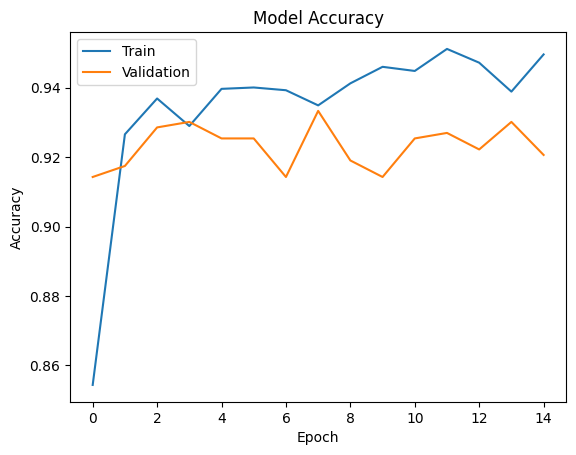

In [ ]:
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.savefig(results_path + "/L_VGG16_accuracy_plot_80_20.png")
plt.show()

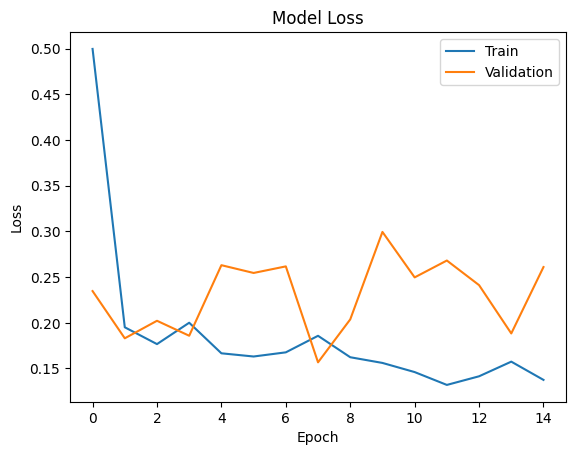

In [ ]:
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.savefig(results_path + "/L_VGG16_loss_plot_80_20.png")
plt.show()

In [ ]:
val_generator.reset()
predictions = model.predict(val_generator)
y_pred = (predictions > 0.5).astype(int).ravel()
y_true = val_generator.classes

20/20 ━━━━━━━━━━━━━━━━━━━━ 337s 17s/step


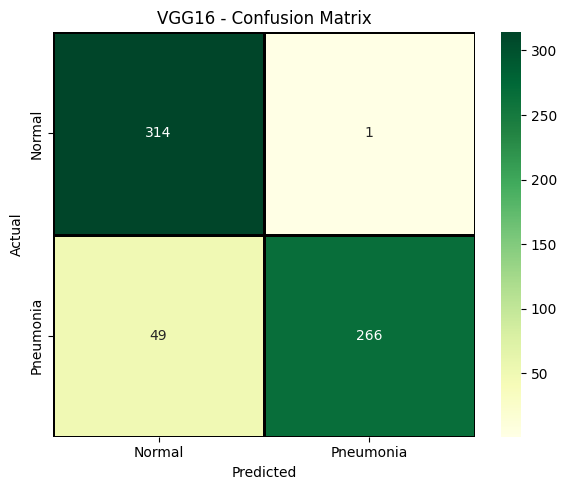

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='YlGn',   # Mixed Yellow-Green
            linewidths=1,
            linecolor='black',
            xticklabels=['Normal','Pneumonia'],
            yticklabels=['Normal','Pneumonia'])

plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('VGG16 - Confusion Matrix')
plt.tight_layout()
plt.savefig(results_path + "/L_VGG16_confusion_matrix_80_20.png")
plt.show()

In [ ]:
report = classification_report(y_true, y_pred, target_names=['Normal','Pneumonia'])
weighted_f1 = f1_score(y_true, y_pred, average='weighted')

print(report)
print("Weighted F1 Score:", weighted_f1)

              precision    recall  f1-score   support

      Normal       0.87      1.00      0.93       315
   Pneumonia       1.00      0.84      0.91       315

    accuracy                           0.92       630
   macro avg       0.93      0.92      0.92       630
weighted avg       0.93      0.92      0.92       630

Weighted F1 Score: 0.9201715171973359


In [ ]:
with open(results_path + "/L_VGG16_classification_report_80_20.txt", "w") as f:
    f.write(report)
    f.write("\nWeighted F1 Score: " + str(weighted_f1))

In [ ]:
final_val_acc = history.history['val_accuracy'][-1]
final_val_loss = history.history['val_loss'][-1]

with open(results_path + "/L_VGG16_final_metrics_80_20.txt", "w") as f:
    f.write("Final Validation Accuracy: " + str(final_val_acc) + "\n")
    f.write("Final Validation Loss: " + str(final_val_loss) + "\n")
    f.write("Weighted F1 Score: " + str(weighted_f1))